In [71]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [92]:
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [73]:
'''
Run on Kaggle or Google Colab
#df = pd.read_csv('kaggle/input/datasets/ibrahimqasimi/tarantino-films-f-words-and-deaths/19_Tarantino_Profanity_Deaths.csv')
'''

#Run it locally
import kagglehub
kagglehub.login()

from pathlib import Path
path = kagglehub.dataset_download("ibrahimqasimi/tarantino-films-f-words-and-deaths")
csv_path = Path(path) / "19_Tarantino_Profanity_Deaths.csv"

df = pd.read_csv(csv_path)

In [74]:
df

,movie,type,word,minutes_in
0,Reservoir Dogs,word,dick,0.40
1,Reservoir Dogs,word,dicks,0.43
2,Reservoir Dogs,word,fucked,0.55
3,Reservoir Dogs,word,fucking,0.61
4,Reservoir Dogs,word,bullshit,0.61
...,...,...,...,...
1889,Jackie Brown,word,motherfucker,141.93
1890,Jackie Brown,word,ass,142.43
1891,Jackie Brown,word,fucking,142.47
1892,Jackie Brown,word,goddamn,142.97


In [75]:
df.shape

(1894, 4)

In [76]:
data_dictionary = {
    "movie": "Title of the Tarantino film in which the event occurred (7 unique films).",
    "type": "Category of the event — either 'word' (a profane word was spoken) or 'death' (a character died).",
    "word": "The specific profane word spoken. Only populated when type == 'word'; None for death events.",
    "minutes_in": "Timestamp (in minutes) within the film when the event occurred.",
}

pd.DataFrame(
    {"Column": data_dictionary.keys(), "Description": data_dictionary.values()}
)

,Column,Description
0,movie,Title of the Tarantino film in which the event...
1,type,Category of the event — either 'word' (a profa...
2,word,The specific profane word spoken. Only populat...
3,minutes_in,Timestamp (in minutes) within the film when th...


In [77]:
data_check = pd.DataFrame({
    "Column": df.columns,
    "Data Type": [df[col].dtype for col in df.columns],
    "Missing Values": [f"{df[col].isna().mean() * 100:.1f}%" for col in df.columns],
    "Unique Values": [df[col].nunique() for col in df.columns],
    "Example Value": [df[col].dropna().iloc[0] if df[col].notna().any() else None for col in df.columns]
})
data_check

,Column,Data Type,Missing Values,Unique Values,Example Value
0,movie,str,0.0%,7,Reservoir Dogs
1,type,str,0.0%,2,word
2,word,str,10.0%,60,dick
3,minutes_in,float64,0.0%,1690,0.4


In [78]:
death_mask  = df['type'] == "death"
df[death_mask]

,movie,type,word,minutes_in
268,Reservoir Dogs,death,NaN,59.93
385,Reservoir Dogs,death,NaN,85.58
386,Reservoir Dogs,death,NaN,85.58
387,Reservoir Dogs,death,NaN,85.81
389,Reservoir Dogs,death,NaN,86.55
...,...,...,...,...
1521,Django Unchained,death,NaN,160.45
1625,Jackie Brown,death,NaN,23.08
1807,Jackie Brown,death,NaN,113.28
1840,Jackie Brown,death,NaN,125.43


In [79]:
df['word'] = df['word'].fillna("None")

In [80]:
duplicated_data = df[df.duplicated()]
print("number of duplicate rows deleted: ", duplicated_data.shape)
df.drop_duplicates(inplace=True)

number of duplicate rows deleted:  (54, 4)


In [81]:
df

,movie,type,word,minutes_in
0,Reservoir Dogs,word,dick,0.40
1,Reservoir Dogs,word,dicks,0.43
2,Reservoir Dogs,word,fucked,0.55
3,Reservoir Dogs,word,fucking,0.61
4,Reservoir Dogs,word,bullshit,0.61
...,...,...,...,...
1889,Jackie Brown,word,motherfucker,141.93
1890,Jackie Brown,word,ass,142.43
1891,Jackie Brown,word,fucking,142.47
1892,Jackie Brown,word,goddamn,142.97


In [82]:
movie_list = list(df['movie'].unique())
movie_list

['Reservoir Dogs',
 'Pulp Fiction',
 'Kill Bill: Vol. 1',
 'Kill Bill: Vol. 2',
 'Inglorious Basterds',
 'Django Unchained',
 'Jackie Brown']

In [83]:
movie_genre = {
    'Reservoir Dogs': 'Crime',
    'Pulp Fiction': 'Crime',
    'Kill Bill: Vol. 1': 'Action',
    'Kill Bill: Vol. 2': 'Action',
    'Inglorious Basterds': 'War',
    'Django Unchained': 'Western',
    'Jackie Brown': 'Crime'
}
def assign_genre(movie: str):
    return movie_genre.get(movie, "Unknown")

df["genre"] = df["movie"].map(assign_genre)

In [84]:
df

,movie,type,word,minutes_in,genre
0,Reservoir Dogs,word,dick,0.40,Crime
1,Reservoir Dogs,word,dicks,0.43,Crime
2,Reservoir Dogs,word,fucked,0.55,Crime
3,Reservoir Dogs,word,fucking,0.61,Crime
4,Reservoir Dogs,word,bullshit,0.61,Crime
...,...,...,...,...,...
1889,Jackie Brown,word,motherfucker,141.93,Crime
1890,Jackie Brown,word,ass,142.43,Crime
1891,Jackie Brown,word,fucking,142.47,Crime
1892,Jackie Brown,word,goddamn,142.97,Crime


### Movie Overivew

In [85]:
movies_overview = df.groupby(['movie','genre']).agg(
    word_count=('type',lambda x: (x == 'word').sum()),
    duration_min=('minutes_in', 'max'),
    death_count=('type', lambda x: (x == 'death').sum())).reset_index()

movies_overview['wpm'] = (movies_overview['word_count'] / movies_overview['duration_min']).round(2)
movies_overview['dpm'] = (movies_overview['death_count'] / movies_overview['duration_min']).round(2)

C:\Users\leeon\AppData\Local\Temp\ipykernel_19300\880311736.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)


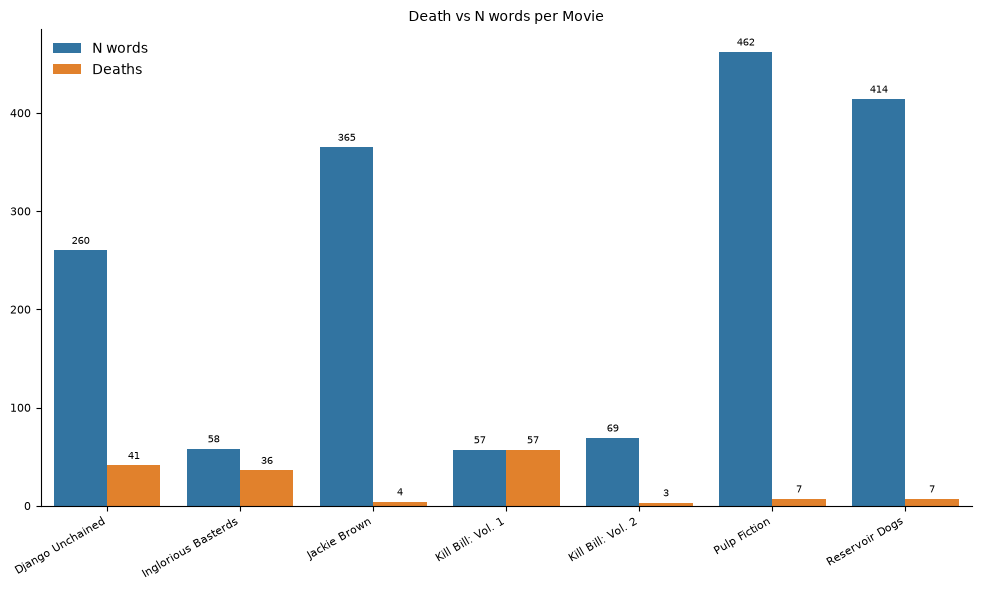

In [86]:
import seaborn as sns
import matplotlib.pyplot as plt

plot_df = movies_overview[['movie', 'word_count', 'death_count']].rename(
    columns={'word_count': 'N words', 'death_count': 'Deaths'}).melt(id_vars='movie', var_name='type', value_name='count')

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=plot_df, x='movie', y='count', hue='type', ax=ax)

for container in ax.containers:
    ax.bar_label(container, fontsize=7, padding=3)

ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
ax.tick_params(axis='y', labelsize=8)
ax.set_title('Death vs N words per Movie', fontsize=10)
ax.set_xlabel('')
ax.set_ylabel('')
ax.legend(loc='upper left', frameon=False)

sns.despine(left=False, right=True, top=True, bottom=False)
plt.tight_layout()

C:\Users\leeon\AppData\Local\Temp\ipykernel_19300\1024910646.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)


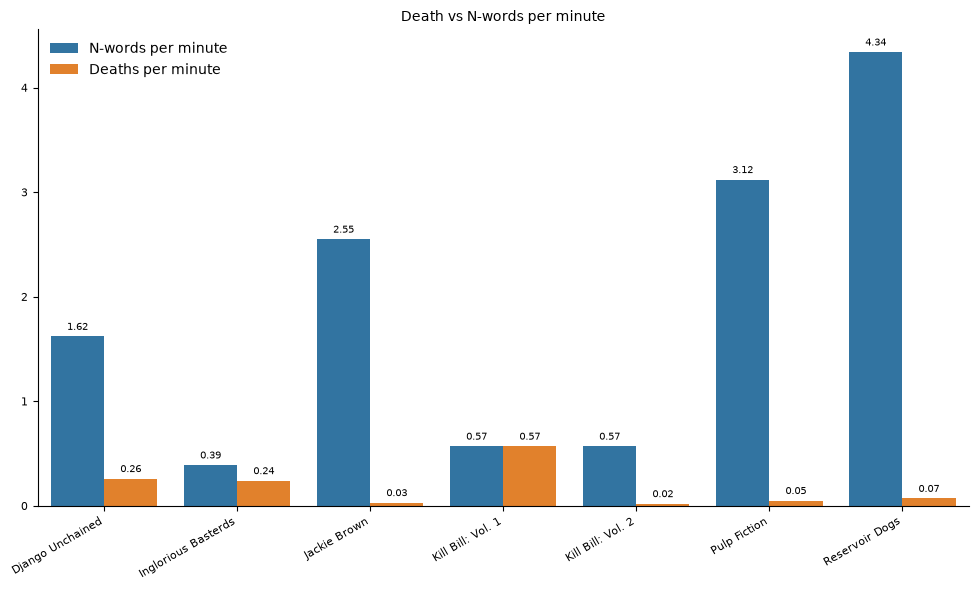

In [87]:
plot_df_metrics = movies_overview[['movie', 'wpm', 'dpm']].rename(
    columns={'wpm': 'N-words per minute', 'dpm': 'Deaths per minute'}).melt(id_vars='movie', var_name='type', value_name='value')

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=plot_df_metrics, x='movie', y='value', hue='type', ax=ax)

for container in ax.containers:
    ax.bar_label(container, fontsize=7, padding=3)

ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
ax.tick_params(axis='y', labelsize=8)
ax.set_title('Death vs N-words per minute', fontsize=10)
ax.set_xlabel('')
ax.set_ylabel('')
ax.legend(loc='upper left', frameon=False)

sns.despine(left=False, right=True, top=True, bottom=False)
plt.tight_layout()

### Genre Overivew

In [88]:
genre_overview = df.groupby(['genre']).agg(
    word_count=('type',lambda x: (x == 'word').sum()),
    duration_min=('minutes_in', 'max'),
    death_count=('type', lambda x: (x == 'death').sum())).reset_index()

genre_overview['wpm'] = (genre_overview['word_count'] / genre_overview['duration_min']).round(2)
genre_overview['dpm'] = (genre_overview['death_count'] / genre_overview['duration_min']).round(2)

C:\Users\leeon\AppData\Local\Temp\ipykernel_19300\932047781.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)


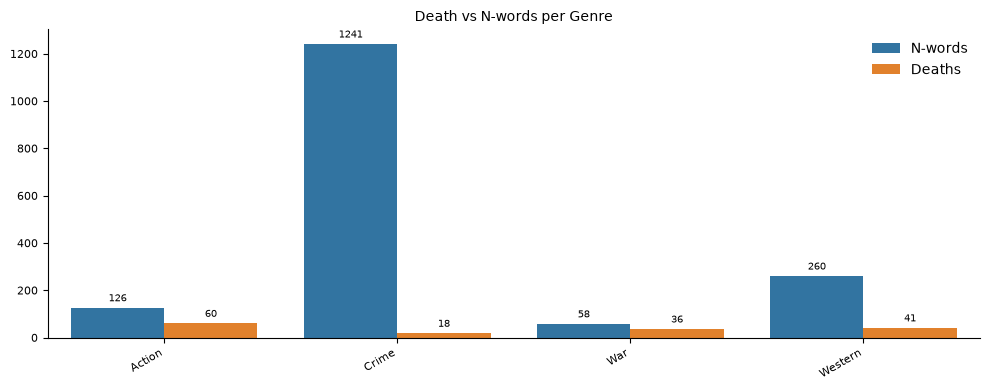

In [89]:
import seaborn as sns
import matplotlib.pyplot as plt

plot_df_v2 = genre_overview[['genre', 'word_count', 'death_count']].rename(
    columns={'word_count': 'N-words', 'death_count': 'Deaths'}).melt(id_vars='genre', var_name='type', value_name='count')

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=plot_df_v2, x='genre', y='count', hue='type', ax=ax)

for container in ax.containers:
    ax.bar_label(container, fontsize=7, padding=3)

ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
ax.tick_params(axis='y', labelsize=8)
ax.set_title('Death vs N-words per Genre', fontsize=10)
ax.set_xlabel('')
ax.set_ylabel('')
ax.legend(loc='upper right', frameon=False)

sns.despine(left=False, right=True, top=True, bottom=False)
plt.tight_layout()

C:\Users\leeon\AppData\Local\Temp\ipykernel_19300\4241579581.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)


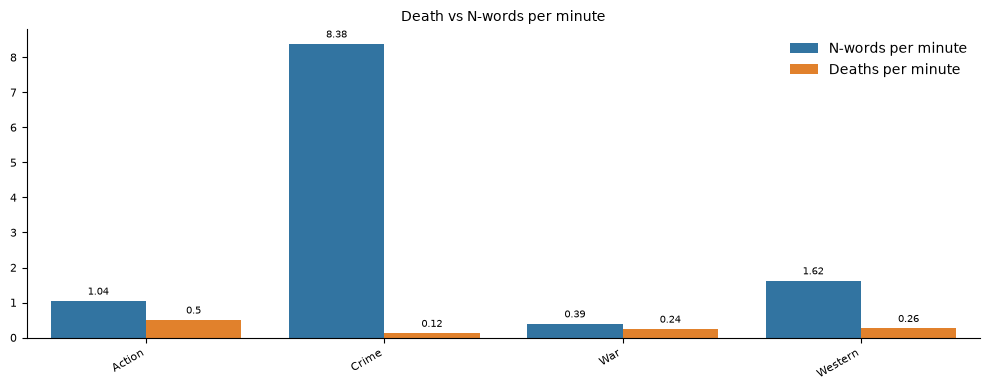

In [90]:
import seaborn as sns
import matplotlib.pyplot as plt

plot_df_v2 = genre_overview[['genre', 'wpm', 'dpm']].rename(
    columns={'wpm': 'N-words per minute', 'dpm': 'Deaths per minute'}).melt(id_vars='genre', var_name='type', value_name='value')

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=plot_df_v2, x='genre', y='value', hue='type', ax=ax)

for container in ax.containers:
    ax.bar_label(container, fontsize=7, padding=3)

ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
ax.tick_params(axis='y', labelsize=8)
ax.set_title('Death vs N-words per minute', fontsize=10)
ax.set_xlabel('')
ax.set_ylabel('')
ax.legend(loc='upper right', frameon=False)

sns.despine(left=False, right=True, top=True, bottom=False)
plt.tight_layout()

In [91]:
# Build a word map for profanity
# Check profanity per minute